# Activation Patching: Finding Causal Circuits

## Introduction and Setup

#### Introduction

Mechanistic interpretability (MI) is a subfield of AI research focused on reverse-engineering the algorithms that Large Language Models (LLMs) learn.

Activation patching is a technique that lets us identify which model components are involved in specific behaviors.

The goal of this notebook is to explore activation patching through the lens of what we'll call the similarity task: where we want the LLM to discern which person in a list has an attribute in common with a specific main person.

### Installs & Imports

In [ ]:
%pip install -q torch nnsight

In [1]:
import torch
from nnsight import LanguageModel

### Model Setup

In [2]:
#model_name = "meta-llama/Llama-3.3-70B-Instruct"
model_name = "meta-llama/Llama-3.2-1B-Instruct"

model = LanguageModel(
    model_name,
    device_map="auto",
    torch_dtype=torch.float16,
    trust_remote_code=True
)

In [3]:
model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 2048)
    (layers): ModuleList(
      (0-15): 16 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=2048, out_features=2048, bias=False)
          (k_proj): Linear(in_features=2048, out_features=512, bias=False)
          (v_proj): Linear(in_features=2048, out_features=512, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (up_proj): Linear(in_features=2048, out_features=8192, bias=False)
          (down_proj): Linear(in_features=8192, out_features=2048, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((2048,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((2048,), eps=1e-05)
    (rotary_emb):

Here we can see that Llama 70B is composed of 80 decoder layers, each of which includes an attention layer, and an MLP layer. Each layer connects to the next via addition with a skip-connection called the **residual stream**. We can get a sense for the relation between the residual stream, the attention layers, and the mlp layers in the diagram below:

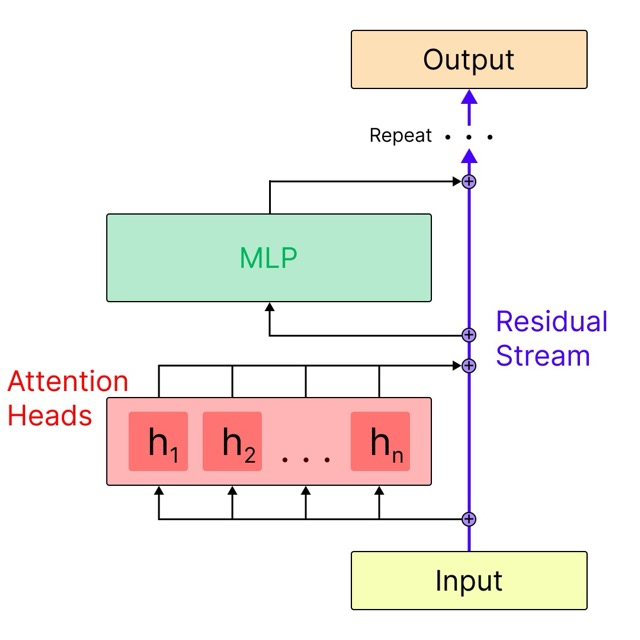

## The Selection Task & Core Concepts

### Defining the Experimental Setup

The similarity task asks the question: How does the model make a connection between two entities that share a common attribute?
For example, when asked "Which of the following entities has a profession in common with Albert Einstein? Brad Pitt, Isaac Newton, Michael Jackson." the model should respond with "Isaac Newton" since Albert Einstein and Isaac Newton are both physicts.

Activation patching can help us understand the LLM components involved in making this connection.

### Prompt Setup

Now, our goal is to track which parts of the model are most necessary for making the correct prediction in this task.
To do this, we'll first need to define two prompts: one which we'll call the **clean prompt** and another we'll call the **corrupt prompt**.

In [4]:
PROMPT_TEMPLATE = "Q: Which of the following entities has a profession in common with {}? {}.\nA:"
PROMPT_TEMPLATE = "Q: Which of the following entities has a profession in common with {}? {}.\nA:"

clean_subj = "Albert Einstein"
corrupt_subj = "Taylor Swift"

entity_list = ["Brad Pitt", "Isaac Newton", "Michael Jackson"]

clean_prompt = PROMPT_TEMPLATE.format(clean_subj, (", ").join(entity_list))
print("Clean Prompt:", clean_prompt, "\n")

corrupt_prompt = PROMPT_TEMPLATE.format(corrupt_subj, (", ").join(entity_list))
print("Corrupt Prompt:", corrupt_prompt)

Clean Prompt: Q: Which of the following entities has a profession in common with Albert Einstein? Brad Pitt, Isaac Newton, Michael Jackson.
A: 

Corrupt Prompt: Q: Which of the following entities has a profession in common with Taylor Swift? Brad Pitt, Isaac Newton, Michael Jackson.
A:


Having the corrupt prompt gives us a version where the correct answer changes. In this case we would expect the model to respond with " Michael Jackson".
Now we'll be able to use activation patching to see which parts of the model are most important for changing the response from Michael Jackson back to Isaac Newton when we patch in the clean version where the only difference is replacing "Taylor Swift" with "Albert Einstein".

Let's make sure that our two subjects are the same token length so we don't have to do any position manipulation.

In [7]:
print(model.tokenizer.encode(" Albert Einstein", add_special_tokens=False))
print(model.tokenizer.encode(" Taylor Swift", add_special_tokens=False))

[17971, 55152]
[16844, 24594]


### Save Clean & Corrupt Target Tokens

Since Isaac Newton gets split into " Isaac" and "Newton", if the model predicts " Isaac" as the next token, we consider that a correct prediction for Isaac Newton. Likewise for the corrupt prediction of Michael Jackson.

In [8]:
clean_target_token_id = model.tokenizer.encode(" Isaac", add_special_tokens=False)
corrupt_target_token_id = model.tokenizer.encode(" Michael", add_special_tokens=False)

## Activation Patching

Patching the residual stream captures everything accumulated up to that point--previous layers plus the outputs of the current sub-blocks we've passed. It tells us: "Does information present *here* matter?

It's useful as a first-pass layer-by-layer, token-by-token sweep to find where in the network the decisive information lives.

But a major caveat is that it doesn't tell us which submodule (mlp layer, attention layer, attention head) created the useful info. It just shows that the info is present in the aggregated site.

### Clean Run

Run the model on the clean input.
Cache activations of a set of given model components.

In [9]:
clean_activations = []
with model.trace(clean_prompt):
    for l in range(model.config.num_hidden_layers):
        residual_output = model.model.layers[l].output[0].save()
        clean_activations.append(residual_output)
    clean_target_logits = model.output.logits[0][-1, clean_target_token_id].item().save()

print(f"{clean_target_logits=}")
print(f"{len(clean_activations)=}")

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/189 [00:00<?, ?B/s]

clean_target_logits=18.390625
len(clean_activations)=16


### Corrupt Run

Run the model on the corrupt prompt and record outputs

In [8]:
with model.trace(corrupt_prompt):
    # Save the output logits
    logits = model.output.logits.save()

    # Save the logits for predicting the clean_target
    clean_target_logits_corrupt = model.output.logits[0][-1, clean_target_token_id].item().save()

# Show the corrupt prediction and logits
corrupt_target_logits = logits[0][-1, corrupt_target_token_id].item()
corrupt_prediction = logits.argmax(dim=-1)[:, -1]
corrupt_token_prediction = model.tokenizer.decode(corrupt_prediction)
print(f"{corrupt_token_prediction=}")
print(f"{corrupt_target_logits=}")

# Show the logits for the clean target on the corrupt run
print(f"{clean_target_logits_corrupt=}")

corrupt_token_prediction=' Michael'
corrupt_target_logits=20.03125
clean_target_logits_corrupt=16.375


### Baseline Logit Difference

This gives us a score of the difference between the models confidence in predicting " Isaac" when we run the clean prompt versus when we run the corrupt prompt.

Note that there are only three possible options, so it is reasonable for this score to remain low even though Isaac would be an incorrect answer in the corrupt prompt.

In [9]:
total_logit_diff = clean_target_logits - clean_target_logits_corrupt
print(f"Baseline logit difference (clean - corrupt): {total_logit_diff}")

Baseline logit difference (clean - corrupt): 3.6875


### Storing Token IDs

The clean input ids will be used for looping through token-by-token.
And both will be used later for decoding back into the tokens for the activation plots.

In [10]:
clean_input_ids = model.tokenizer.encode(clean_prompt)
corrupt_input_ids = model.tokenizer.encode(corrupt_prompt)

assert len(clean_input_ids) == len(corrupt_input_ids)

### Patched Run

Run the model on the corrupt input with residual stream activations restored from the clean run.

In [ ]:
from tqdm import trange

patched_activations = []

# Loop through the model layers
for l in trange(model.config.num_hidden_layers):

    patch_at_layer = []

    # For each token position
    for t in range(len(clean_input_ids)):

        # We run the model on the corrupt prompt
        with model.trace(corrupt_prompt):

            # Replace the residual stream output with the clean_activations at that token
            model.model.layers[l].output[0][:, t, :] = clean_activations[l][:, t, :]

            # Get the model output logits
            patched_logits = model.output.logits[0].save()

            # Get the logits for the clean target
            patched_target_logits = patched_logits[-1, clean_target_token_id].item().save()

            # Calculate the logit difference
            logit_diff = patched_target_logits - clean_target_logits_corrupt

            # Normalize the logit difference
            if total_logit_diff == 0:
                normalized_score = 0.0
            else:
                normalized_score = logit_diff / total_logit_diff

            normalized_score = normalized_score.save()

        # Print the layer, token, and logit difference
        print(f"L{l}, T{t}, LD={normalized_score}")

        # Append the token to our list of logit differences at the current layer
        patch_at_layer.append(normalized_score)
    
    # Append each layer's logit differences list to our overall list of lists
    patched_activations.append(patch_at_layer)

print(f"\\nPatched activations shape: {len(patched_activations)} layers x {len(patched_activations[0])} tokens")


## Plotting Logic

We want a heatmap that shows us the indirect effect of our patching from clean to corrupt at each token and each layer.
This will show us which tokens are the most necessary for predicting the correct answer.

Scores shape after transpose: (28, 80)
Data range: min=-0.2458, max=1.1144


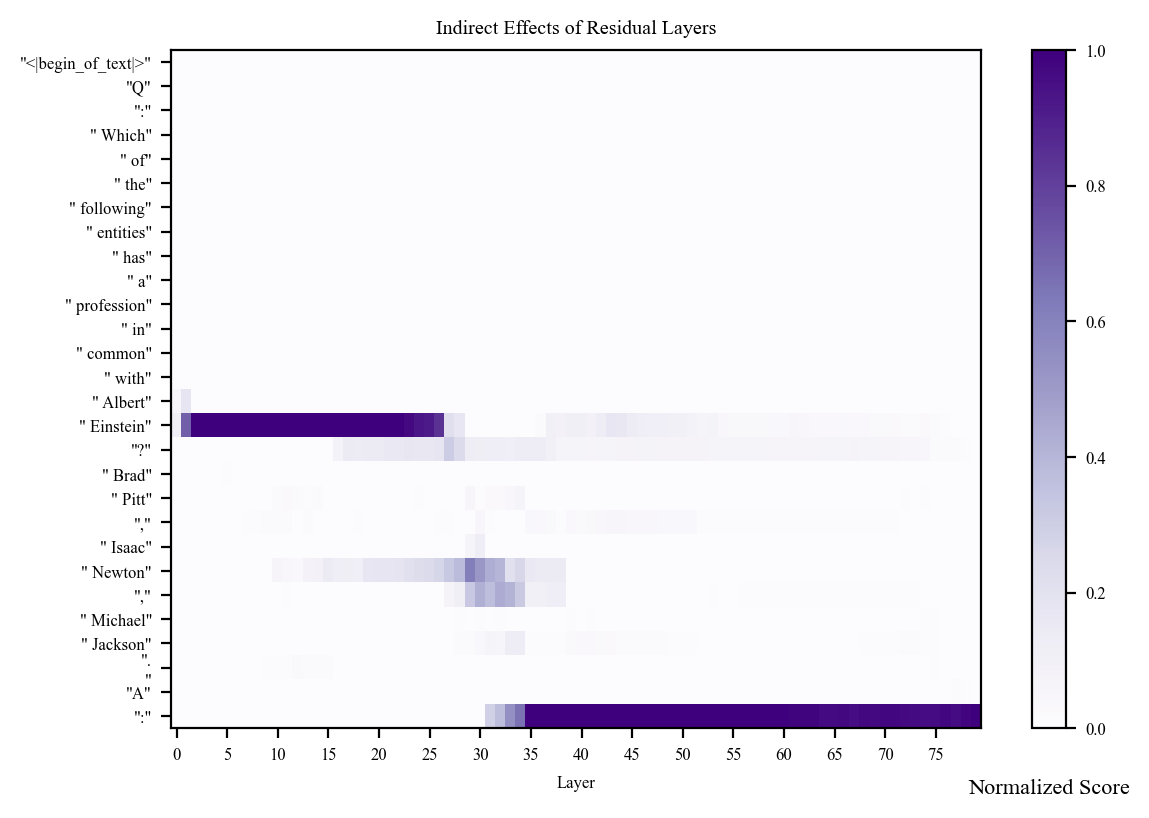

Data shape: (28, 80)
Number of tokens: 28


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2D array: layers as rows, tokens as columns, then transpose
scores = np.array(patched_activations).T  # Transpose so tokens are rows, layers are columns
print(f"Scores shape after transpose: {scores.shape}")

# Decode tokens to actual text
corrupt_tokens = [model.tokenizer.decode([token_id]) for token_id in corrupt_input_ids]
clean_tokens = [model.tokenizer.decode([token_id]) for token_id in clean_input_ids]

# Create token labels
tokens = []
for idx, (corrupt_tok, clean_tok) in enumerate(zip(corrupt_tokens, clean_tokens)):
    tokens.append(f'"{clean_tok}"')

# We will truncate to the 0 to 1 range to prioritize positive values
# but this is the full actual range.
print(f"Data range: min={scores.min():.4f}, max={scores.max():.4f}")

plt.rcdefaults()
with plt.rc_context(
    rc={
        "font.family": "Times New Roman",
        "font.size": 6,
    }
):
    # Set figure size
    fig, ax = plt.subplots(
        figsize=(
            6,
            len(tokens) * 0.08 + 1.8
        ),
        dpi=200
    )
    
    # Scale range
    scale_kwargs = {
        "vmin": 0,
        "vmax": 1
    }

    heatmap = ax.pcolor(
        scores,
        cmap="Purples",
        **scale_kwargs,
    )

    ax.invert_yaxis()
    
    # Y-axis: token labels (rows)
    ax.set_yticks([0.5 + i for i in range(scores.shape[0])])  # Number of tokens
    ax.set_yticklabels(tokens)
    
    # X-axis: layer labels (columns)
    num_layers = scores.shape[1]
    tick_indices = np.arange(0, num_layers, 5)
    ax.set_xticks(tick_indices + 0.5)  # Number of layers
    ax.set_xticklabels(tick_indices)

    title = f"Indirect Effects of Residual Layers"
    ax.set_title(title)

    ax.set_xlabel("Layer")
    #ax.set_ylabel("Tokens")

    color_scale = plt.colorbar(heatmap)
    color_scale.ax.set_title(
        f"Normalized Score",
        y=-0.12,
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

print(f"Data shape: {scores.shape}")
print(f"Number of tokens: {len(tokens)}")



Based on the above plot, we can make the following suppositions:

- The early activations at the " Einstein" token suggest that the earlier layers rely heavily on the representation of Albert Einstein for making the correct prediction. Perhaps the model uses this time to understand who Albert Einstein is, what attributes he possesses, what his profession is.

- The activations in the middle layers for the " Newton" and "," tokens suggest this is when the model is retriving information about Isaac Newton to inform its prediction.

- By layer 34, the model activates strongest at the last token position, suggesting that the relevant information for making the correct prediction has already been extracted by this point.

## Final Thoughts

Patching at the residual stream level is informative, but it is the most coarse-grained form of patching we can do.
For a more fine-grained analysis, we will want to observe the activations in the mlp and attention layers, which we will do in the next notebook.